In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Ice_cream selling data.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


#### Data is `linear` or `non-linear`

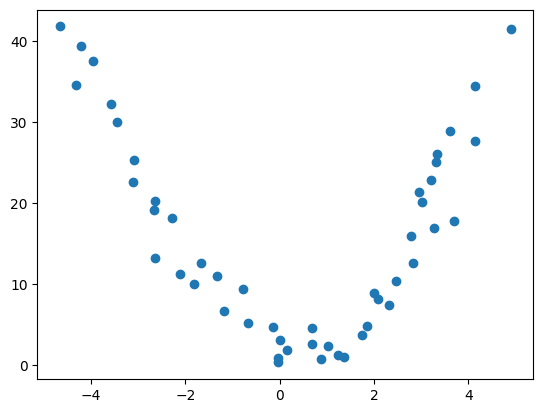

In [4]:
#1)scatterplot
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])

Relation between X and y follow `U pattern` which is `non-linear`

In [5]:
#2)corr()
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


Since the data is non-linear,here we confrimed by using corr()

Relation between Temperature (°C)	and  Ice Cream Sales (units) is `-0.175184`

correlation value is close to zero.so the data is `non-linear`

In [6]:
X = df[['Temperature (°C)']]
y = df['Ice Cream Sales (units)']

### Train test split

In [7]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,train_size=0.8,random_state=42)

### Model creation and training

In [8]:
model = LinearRegression()
model.fit(xtrain,ytrain) #learns the pattern(mx+c) from xtrain and ytrain

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-1.15]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Temperature (°C)']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,17.14
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


### Model evaluation

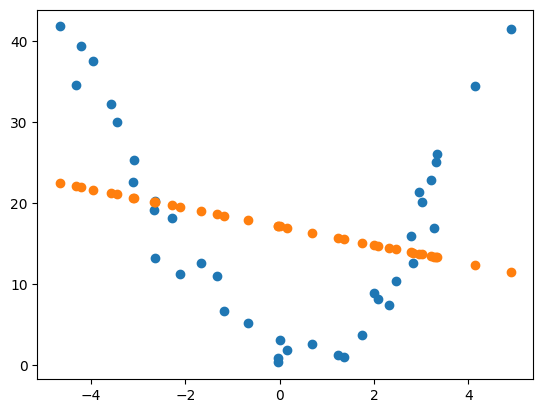

In [9]:
#scatterplot
ypred_train = model.predict(xtrain)
plt.scatter(xtrain,ytrain)
plt.scatter(xtrain,ypred_train)

In [10]:
#metrics
from sklearn.metrics import r2_score

train_score = r2_score(ytrain,ypred_train)
print(f"Train score : {train_score}")

Train score : 0.06579063815950037


### Polynomial Features

In [11]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=4)
updated_xtrain = poly.fit_transform(xtrain)
updated_xtest = poly.transform(xtest)

In [12]:
xtrain

,Temperature (°C)
12,-2.111870
4,-3.578554
34,2.318591
8,-2.672461
3,-3.949661
6,-3.108440
40,3.211366
41,3.270044
46,4.130868
15,-1.326379


In [13]:
updated_xtrain

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00,
        -9.41892528e+00,  1.98915428e+01],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01,
        -4.58271260e+01,  1.63994832e+02],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00,
         1.24644343e+01,  2.88999281e+01],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00,
        -1.90868405e+01,  5.10088335e+01],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01,
        -6.16140128e+01,  2.43354469e+02],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00,
        -3.00349918e+01,  9.33619735e+01],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01,
         3.31184096e+01,  1.06355339e+02],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01,
         3.49671967e+01,  1.14344274e+02],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01,
         7.04894205e+01,  2.91182489e+02],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00,
        -2.33347362e+00

In [14]:
model = LinearRegression()
model.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0. ,-1.58, 2.49, 0.07,-0.03]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.113
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[836.02,243.92, 13.18, 7.34, 0. ]"


In [15]:
updated_xtrain

array([[ 1.00000000e+00, -2.11186969e+00,  4.45999359e+00,
        -9.41892528e+00,  1.98915428e+01],
       [ 1.00000000e+00, -3.57855372e+00,  1.28060467e+01,
        -4.58271260e+01,  1.63994832e+02],
       [ 1.00000000e+00,  2.31859124e+00,  5.37586534e+00,
         1.24644343e+01,  2.88999281e+01],
       [ 1.00000000e+00, -2.67246083e+00,  7.14204687e+00,
        -1.90868405e+01,  5.10088335e+01],
       [ 1.00000000e+00, -3.94966109e+00,  1.55998227e+01,
        -6.16140128e+01,  2.43354469e+02],
       [ 1.00000000e+00, -3.10844012e+00,  9.66239999e+00,
        -3.00349918e+01,  9.33619735e+01],
       [ 1.00000000e+00,  3.21136614e+00,  1.03128725e+01,
         3.31184096e+01,  1.06355339e+02],
       [ 1.00000000e+00,  3.27004407e+00,  1.06931882e+01,
         3.49671967e+01,  1.14344274e+02],
       [ 1.00000000e+00,  4.13086796e+00,  1.70640701e+01,
         7.04894205e+01,  2.91182489e+02],
       [ 1.00000000e+00, -1.32637898e+00,  1.75928121e+00,
        -2.33347362e+00

In [16]:
xtrain

,Temperature (°C)
12,-2.111870
4,-3.578554
34,2.318591
8,-2.672461
3,-3.949661
6,-3.108440
40,3.211366
41,3.270044
46,4.130868
15,-1.326379


In [17]:
#scatterplot
'''.
ypred_train = model.predict(xtrain)
ValueError: X has 1 features, but LinearRegression is 
expecting 2 features as input.
'''

'.\nypred_train = model.predict(xtrain)\nValueError: X has 1 features, but LinearRegression is \nexpecting 2 features as input.\n'

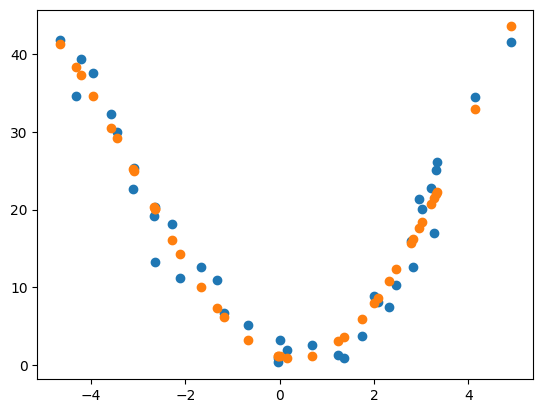

In [18]:
ypred_train = model.predict(updated_xtrain)
plt.scatter(updated_xtrain[:,1],ytrain)
plt.scatter(updated_xtrain[:,1],ypred_train)

In [19]:
updated_xtrain[:,1]

array([-2.11186969, -3.57855372,  2.31859124, -2.67246083, -3.94966109,
       -3.10844012,  3.21136614,  3.27004407,  4.13086796, -1.32637898,
       -2.65228679, -1.17312327,  0.68878091,  2.0751006 ,  1.74000001,
       -4.66226268,  3.33593241,  1.99931037, -3.4557117 ,  1.35981267,
       -2.288264  ,  2.78483646, -4.31655945, -0.03389529, -4.21398476,
        2.83176021,  2.471946  ,  0.14924457,  3.02087431, -2.65149803,
        0.0086077 , -0.6737528 ,  4.89903151, -0.0361565 , -3.08130332,
        3.31607252, -1.66034773,  1.24071162,  2.95993209])

In [20]:
#Train score
train_score = r2_score(ytrain,ypred_train)
print(f"Train Score : {train_score}")

Train Score : 0.9590068634754769


In [21]:
#Test score
ypred_test = model.predict(updated_xtest)
test_score = r2_score(ytest,ypred_test)
print(f"Test Score : {test_score}")

Test Score : 0.8054468908427623


degree=2

Train Score : 0.9413665676490518
Test Score : 0.843055137193884

degree=3

Train Score : 0.9469116778215552
Test Score : 0.8405107685716909

degree=4

Train Score : 0.9590068634754769
Test Score : 0.8054468908427672